# Unscented Kalman Filter

This notebook demonstrates a **1D Unscented Kalman filter** by introducing nonlinearities on the underlying dynamical model.

## 1. Model overview

The real behavior of the system is now modeled as an accelerated moving particle
with position/velocity nonlinearities driven by random jerk.

Also in this case, the state consists of position $x$, velocity $v$ and
acceleration $a$. The true dynamics of the point mass is assumed to be described
by the state equations

$$
\begin{bmatrix} x_{k+1} \\ v_{k+1} \\ a_{k+1} \end{bmatrix} = 
    \underbrace{
        \begin{bmatrix} 
            x_k + dt v_k + \frac{1}{2}dt^2a_k \\
            v_k + dt a_k \\
            a_k + dt \left(-\alpha \sin(x_k) - \beta v_k^2 \text{sgn}(v_k) \right)
        \end{bmatrix}}_{f(\cdot)}
        + \mathsf{w}_k
$$

with process noise $\mathsf{w}_k\sim\mathcal{N}(0,Q)$ where

$$
Q = \sigma_j^2 \begin{bmatrix} \tfrac{dt^5}{20} & \tfrac{dt^4}{8} & \tfrac{dt^3}{6} \\ \tfrac{dt^4}{8}  & \tfrac{dt^3}{3} & \tfrac{dt^2}{2} \\ \tfrac{dt^3}{6}  & \tfrac{dt^2}{2} & dt \end{bmatrix}.
$$

Here:
* $\alpha$ can model a nonlinear position-dependent restoring effect,
* $\beta v^2 \text{sgn}(v)$ is a nonlinear drag term.

Note that for $\alpha=\beta=0$ we fall back to the Linear model hence non-linear strenght can be analyzed.

Finally, we assume also a non-linear measurement range-like model:
$$
y^{(pos)}_k = \underbrace{\sqrt{x_k^2 + L^2}}_{h(\cdot)} + \mathsf{v}_k,\quad 
$$

with known offset $L$ where $\mathsf{v}_k\sim\mathcal{N}(0,R), R=\sigma_{\mathsf{v}}^2$.

## 2. Imports and setup

In [77]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from linear_and_nonlinear_kf.utils import simulate_nonlinear_model  # used to simulate motion and measurements

## 2. UKF model

For the UKF, differently from the EKF, no explicit linearization but rather sigma-points computation.

$$
\lambda = \alpha^2 (n + \kappa) - n
$$

$$
\chi_0 = \mathbf{x}
$$

$$
\chi_i = \mathbf{x} + \left[\sqrt{(n+\lambda)\mathbf{P}}\right]_i, \quad i = 1, \dots, n
$$

$$
\chi_{i+n} = \mathbf{x} - \left[\sqrt{(n+\lambda)\mathbf{P}}\right]_i, \quad i = 1, \dots, n
$$

As well as mean and covariance weight computation used to estimate first and second order moment of the distribution

$$
W_0^{(m)} = \frac{\lambda}{n+\lambda}, \quad
W_0^{(c)} = \frac{\lambda}{n+\lambda} + (1 - \alpha^2 + \beta)
$$

$$
W_i^{(m)} = W_i^{(c)} = \frac{1}{2(n+\lambda)}, \quad i = 1,\dots,2n
$$


In [78]:
def unscented_kalman_filter(
    y: np.ndarray,
    dt: float,
    x0: np.ndarray,
    P0: np.ndarray,
    sigma_j: float,
    sigma_y: float,
    alpha: float = 0.0,
    beta: float = 0.0,
    L: float = 1.0,
    C: float = 0.0,
    ukf_alpha: float = 1e-3,
    ukf_beta: float = 2.0,
    ukf_kappa: float = 0.0
):
    """
    Unscented Kalman Filter for the nonlinear 1D motion model with state

        x = [position, velocity, acceleration]^T

    Process model:
        p_{k+1} = p_k + dt*v_k + 0.5*dt^2*a_k
        v_{k+1} = v_k + dt*a_k
        a_{k+1} = a_k + dt*(-alpha*sin(p_k) - beta*v_k*abs(v_k)) + w_k

    Measurement model:
        y_k = sqrt(p_k^2 + L^2) + v_k^m

    Args:
        y (np.ndarray): array of scalar measurements.
        dt (float): time step.
        x0 (np.ndarray): initial state [position, velocity, acceleration].
        P0 (np.ndarray): initial 3x3 covariance matrix.
        sigma_j (float): jerk-noise standard deviation used to build Q.
        sigma_y (float): measurement noise standard deviation.
        alpha (float): nonlinear position coefficient in process model.
        beta (float): nonlinear drag coefficient in process model.
        L (float): offset parameter in measurement model.
        C (float): coefficient of directional info in measurement model.
        ukf_alpha (float): UKF spread parameter.
        ukf_beta (float): UKF prior-shape parameter (2.0 is standard for Gaussian priors).
        ukf_kappa (float): UKF secondary scaling parameter.

    Returns:
        np.ndarray: filtered state estimates of shape (N, 3).
        np.ndarray: filtered covariance matrices of shape (N, 3, 3).
    """

    def f(x: np.ndarray) -> np.ndarray:
        """Nonlinear process model. Input/output shape: (3, 1)."""
        p, v, a = x.flatten()
        return np.array([
            [p + dt * v + 0.5 * dt**2 * a],
            [v + dt * a],
            [a + dt * (-alpha * np.sin(p) - beta * v * abs(v))]
        ])

    def h(x: np.ndarray) -> np.ndarray:
        """Nonlinear scalar measurement model. Output shape: (1, 1)."""
        p = float(x[0, 0])
        return np.array([[np.sqrt(p**2 + L**2) + C*p]])

    def chol_psd(M: np.ndarray, eps: float = 1e-9) -> np.ndarray:
        """
        Stable Cholesky for symmetric positive semidefinite matrices.
        Adds small diagonal jitter if needed.
        """
        M = 0.5 * (M + M.T)
        jitter = 0.0
        for _ in range(6):
            try:
                return np.linalg.cholesky(M + jitter * np.eye(M.shape[0]))
            except np.linalg.LinAlgError:
                jitter = eps if jitter == 0.0 else 10.0 * jitter
        raise np.linalg.LinAlgError("Cholesky decomposition failed for covariance matrix.")

    def sigma_points(x: np.ndarray, P: np.ndarray):
        """
        Generate 2n+1 sigma points for state mean x and covariance P.
        Returns array of shape (2n+1, n, 1).
        """
        n = x.shape[0]
        lam = ukf_alpha**2 * (n + ukf_kappa) - n
        c = n + lam

        S = chol_psd(c * P)
        points = [x.copy()]

        for i in range(n):
            col = S[:, [i]]
            points.append(x + col)
            points.append(x - col)

        return np.array(points), lam, c

    def sigma_weights(n: int):
        """Compute UKF signa weights from state dimension
        
        Args:
            n (int): state dim
        
        Returns:
            Wm (np.array (2n+1))
            Wc (np.array (2n+1))
        """
        # UKF weights
        lam = ukf_alpha**2 * (n + ukf_kappa) - n
        c = n + lam

        Wm = np.full(2 * n + 1, 1.0 / (2.0 * c))
        Wc = np.full(2 * n + 1, 1.0 / (2.0 * c))
        Wm[0] = lam / c
        Wc[0] = lam / c + (1.0 - ukf_alpha**2 + ukf_beta)
        return Wm, Wc


    # State dimension 
    n = 3

    # Noise covariances
    Q = sigma_j**2 * np.array([
        [dt**5 / 20.0, dt**4 / 8.0, dt**3 / 6.0],
        [dt**4 / 8.0,  dt**3 / 3.0, dt**2 / 2.0],
        [dt**3 / 6.0,  dt**2 / 2.0, dt]
    ])
    R = np.array([[sigma_y**2]])

    # Initial state
    x = x0.reshape(n, 1).astype(float)
    P = P0.astype(float).copy()

    xs = []
    Ps = []

    # sigma weights
    Wm, Wc = sigma_weights(n)

    for yk in y:
        yk = np.array([[float(yk)]])

        # ---- Predict ----
        # use the current state mean value to generate the sigma points
        X, _, _ = sigma_points(x, P)  # shape: (2n+1, n, 1)

        # forward the points through the nonlinear state equation
        X_pred = np.array([f(Xi) for Xi in X])  # shape: (2n+1, n, 1)

        # update state prediction using transformed points and mean weights Wm
        x_pred = np.zeros((n, 1))
        for i in range(2 * n + 1):
            x_pred += Wm[i] * X_pred[i]

        # compute error cov as sample cov between mean prediction and transformed points
        P_pred = Q.copy()
        for i in range(2 * n + 1):
            dx = X_pred[i] - x_pred
            P_pred += Wc[i] * (dx @ dx.T)

        # ---- Predict measurement ----
        # estimate measurement point using transformed points forwarded through nonlinear measurement equation
        Y_pred_pts = np.array([h(Xi) for Xi in X_pred])  # shape: (2n+1, 1, 1)

        # compute average value using mean weights
        y_pred = np.zeros((1, 1))
        for i in range(2 * n + 1):
            y_pred += Wm[i] * Y_pred_pts[i]

        # compute measurement sample cov
        S = R.copy()
        for i in range(2 * n + 1):
            dy = Y_pred_pts[i] - y_pred
            S += Wc[i] * (dy @ dy.T)

        # Cross-covariance
        Pxy = np.zeros((n, 1))
        for i in range(2 * n + 1):
            dx = X_pred[i] - x_pred
            dy = Y_pred_pts[i] - y_pred
            Pxy += Wc[i] * (dx @ dy.T)

        # ---- Update ----
        K = Pxy @ np.linalg.inv(S)
        innovation = yk - y_pred

        x = x_pred + K @ innovation
        P = P_pred - K @ S @ K.T
        P = 0.5 * (P + P.T)  # enforce symmetry numerically

        xs.append(x.flatten())
        Ps.append(P.copy())

    return np.array(xs), np.array(Ps)

## 3. Run simulation and filter

In [ ]:
# define the parameters
dt = 0.1
n_steps = 200
p0 = 0
v0 = 0
a0 = 0

# true values used to generate motion
sigma_j_true = 0.8
sigma_y_true = 2.0

# model parameters
alpha = 0.1
beta = 0.05
L = 1.0
C = 0.5

# generate the "true" motion and measurements. acceleration measurements saved just for checking
true_pos, true_vel, true_acc, y = simulate_nonlinear_model(
    n_steps, dt,
    p0, v0, a0,
    sigma_j_true, sigma_y_true,
    alpha, beta, L, C,
    seed=42
)

# defined the filter noise parameters
# Currently equal to the true ones -> This is the best we can do!!!
sigma_a_filter = 0.8
sigma_y_filter = 2.0

# initialize the filter: state estimate and error cov matrix
x0 = np.array([0.0, 0.0, 0.0])
# x0 = 0.0001*np.random.rand(3)  # try with small perturbation
# x0 = np.random.rand(3)  # try with larger perturbation
# print(x0)
# P0 = np.diag([10.0**2, 10.0**2, 5.0**2])
P0 = np.diag([1.0, 1.0, 1.0])

# filter parameters
ukf_alpha = 1
ukf_beta = 2
ukf_kappa = 0
# run the filter
xs, Ps = unscented_kalman_filter(
    y, dt, x0, P0, sigma_a_filter, sigma_y_filter, alpha, beta, L, C, ukf_alpha, ukf_beta, ukf_kappa
)

# extract the results
est_pos = xs[:, 0]
est_vel = xs[:, 1]
est_acc = xs[:, 2]
t = np.arange(n_steps) * dt
sigma_pos = np.sqrt(Ps[:, 0, 0])
sigma_vel = np.sqrt(Ps[:, 1, 1])
sigma_acc = np.sqrt(Ps[:, 2, 2])

# some MSE computations
mse_pos = np.mean((true_pos - est_pos)**2)
mse_vel = np.mean((true_vel - est_vel)**2)
mse_acc = np.mean((true_acc - est_acc)**2)

print(f"Position MSE: {mse_pos:.4f}")
print(f"Velocity MSE: {mse_vel:.4f}")
print(f"Acceleration MSE: {mse_acc:.4f}")

# compute alternative estimates
est_vel_from_y = np.diff(y) / dt # naive estimates
est_vel_from_est_pos = np.diff(est_pos) / dt # from pos estimates
t_est_vel = t[1:]   # shorter by one


Position MSE: 3.7580
Velocity MSE: 2.7293
Acceleration MSE: 0.6961


## 4. Results: Position and Velocity - True vs Estimated

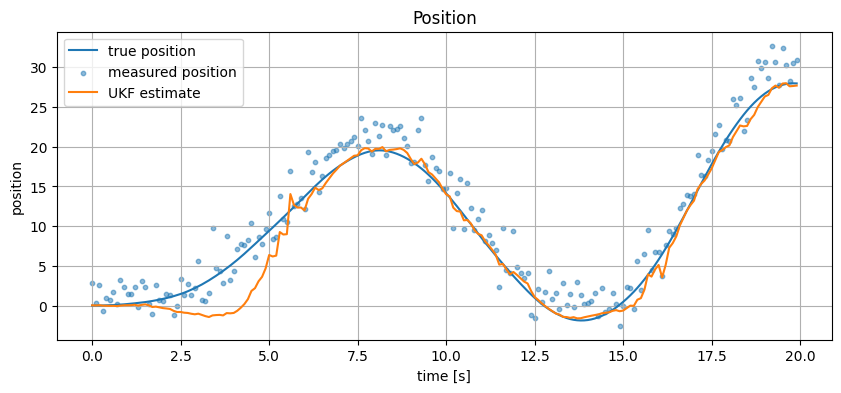

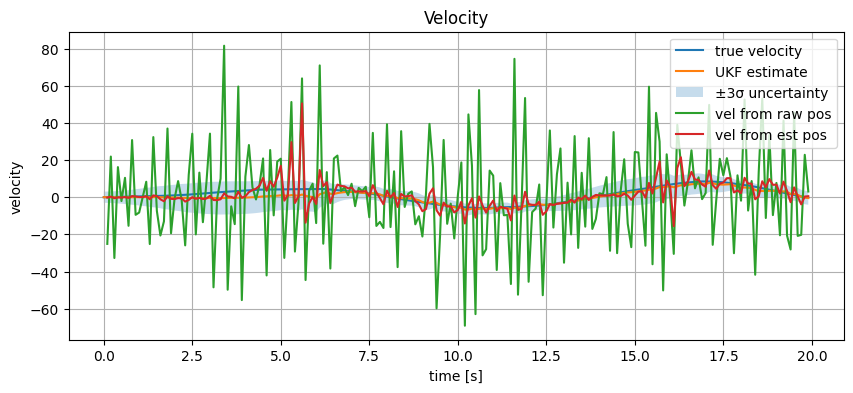

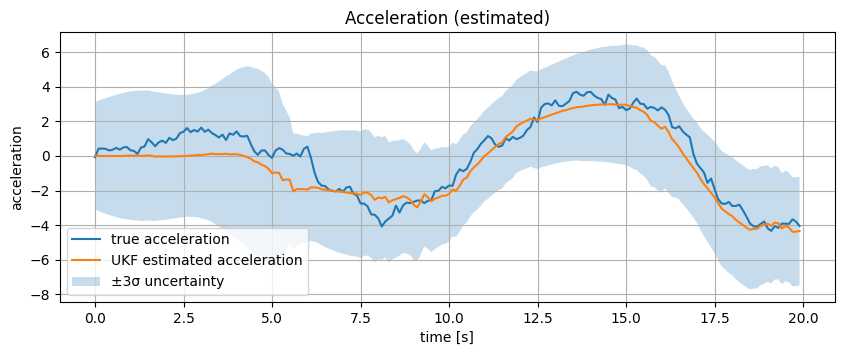

In [80]:
# plot the position
plt.figure(figsize=(10, 4))
plt.plot(t, true_pos, label='true position')
plt.scatter(t, y, s=10, alpha=0.5, label='measured position')
plt.plot(t, est_pos, label='UKF estimate')
# plt.fill_between(t, est_pos - 3*sigma_pos, est_pos + 3*sigma_pos, alpha=0.25, label="±3σ uncertainty")
plt.xlabel('time [s]')
plt.ylabel('position')
plt.title('Position')
plt.legend()
plt.grid(True)
plt.show()


# plot the velocity
plt.figure(figsize=(10, 4))
plt.plot(t, true_vel, label='true velocity')
plt.plot(t, est_vel, label='UKF estimate')
plt.fill_between(t, est_vel - 3*sigma_vel, est_vel + 3*sigma_vel, alpha=0.25, label="±3σ uncertainty")
plt.plot(t_est_vel, est_vel_from_y, label="vel from raw pos")
plt.plot(t_est_vel, est_vel_from_est_pos, label="vel from est pos")
plt.xlabel('time [s]')
plt.ylabel('velocity')
plt.title('Velocity')
plt.legend()
plt.grid(True)
plt.show()

# plot the acceleration JUST FOR CHECKING
plt.figure(figsize=(10, 3.5))
plt.plot(t, true_acc, label='true acceleration')
plt.plot(t, est_acc, label='UKF estimated acceleration')
plt.fill_between(t, est_acc - 3*sigma_acc, est_acc + 3*sigma_acc, alpha=0.25, label="±3σ uncertainty")
plt.xlabel('time [s]')
plt.ylabel('acceleration')
plt.title('Acceleration (estimated)')
plt.grid(True)
plt.legend()
plt.show()

